In [74]:
import pandas as pd
import numpy as np
from pathlib import Path
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import shap

In [75]:
data_path = Path.cwd().parent / 'data'
random_state = 42

In [76]:
training_data = pd.read_csv(
    data_path / 'training_data.csv',
    usecols=[
        'category_id',
        'price',
        'is_first_time_customer',
        'order_day_of_week',
        'price_percentile',
        'returned'
    ]
)
X = training_data[[
    'category_id',
    'price',
    'is_first_time_customer',
    'order_day_of_week',
    'price_percentile'
]]
Y = training_data['returned']

In [77]:

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=random_state)

In [78]:
model = xgb.XGBClassifier()
model.load_model(data_path / 'xgb_model.ubj')

In [79]:
predictions_prob = model.predict_proba(x_test)
print(predictions_prob[:8, :])

[[0.62093925 0.37906078]
 [0.68288255 0.31711742]
 [0.6201457  0.37985432]
 [0.6701803  0.3298197 ]
 [0.6522846  0.34771535]
 [0.59364176 0.40635827]
 [0.482993   0.517007  ]
 [0.53072107 0.4692789 ]]


In [80]:
# convert to 0-1 predictions
predictions = np.argmax(predictions_prob, axis=1)
print(predictions[:8])

[0 0 0 0 0 0 1 0]


In [81]:
# find examples for each prediction outcome
actual = y_test.to_numpy()
indices_by_outcome = {
    'false_negatives': np.flatnonzero((actual == 1) & (predictions == 0)),
    'false_positives': np.flatnonzero((actual == 0) & (predictions == 1)),
    'true_negatives': np.flatnonzero((actual == 0) & (predictions == 0)),
    'true_positives': np.flatnonzero((actual == 1) & (predictions == 1))
}
for outcome, indices in indices_by_outcome.items():
    print(f'{outcome}: {indices[:8]}...')

false_negatives: [  7  18  36  46  50  67  81 123]...
false_positives: [ 6 11 13 16 21 22 23 24]...
true_negatives: [0 1 2 3 4 5 8 9]...
true_positives: [ 32  34  76 124 199 238 263 348]...


In [82]:
# key metrics
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.93      0.77      0.84     10917
           1       0.14      0.38      0.21      1083

    accuracy                           0.73     12000
   macro avg       0.53      0.57      0.52     12000
weighted avg       0.86      0.73      0.78     12000



In [83]:
tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()
print(f'tn: {tn}, fp: {fp}, fn: {fn}, tp: {tp}')

tn: 8407, fp: 2510, fn: 672, tp: 411


In [84]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(x_test)

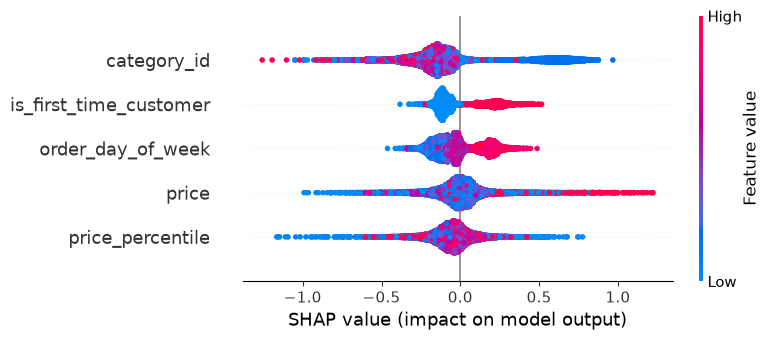

In [85]:
shap.summary_plot(shap_values, x_test)

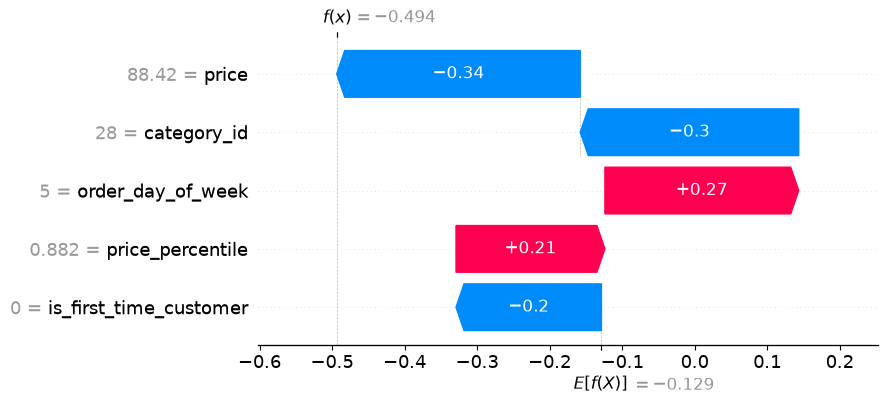

In [86]:
# decision for true negative example
shap.plots.waterfall(shap_values[indices_by_outcome['true_negatives'][0]])

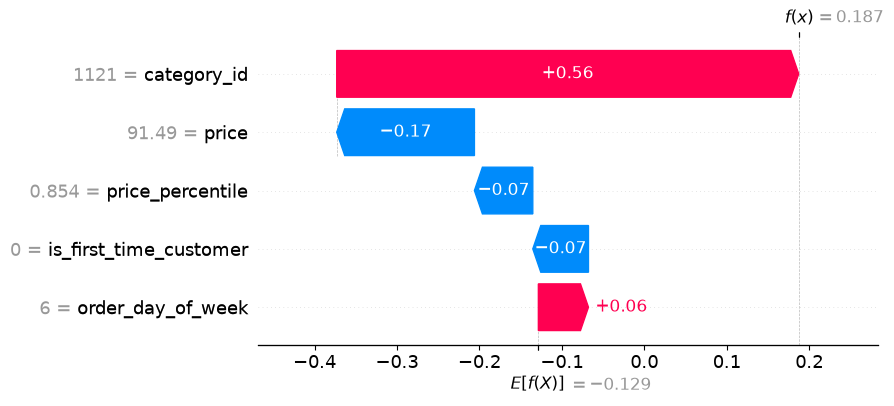

In [87]:
# plot for true positive example
shap.plots.waterfall(shap_values[indices_by_outcome['true_positives'][0]])

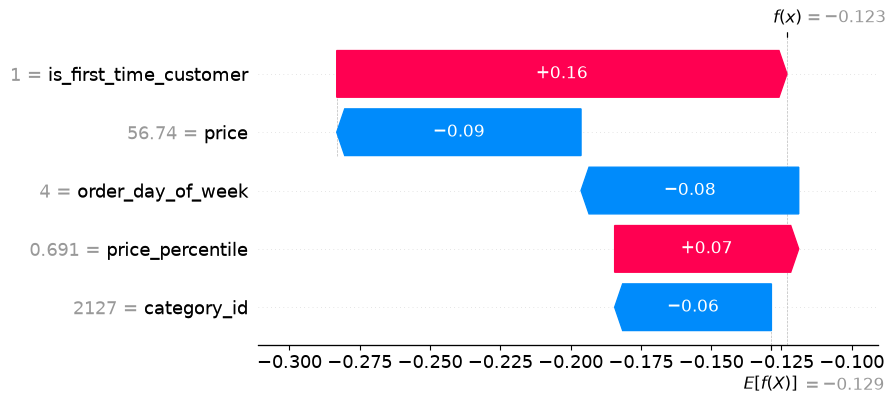

In [88]:
# plot for false negative example
shap.plots.waterfall(shap_values[indices_by_outcome['false_negatives'][0]])

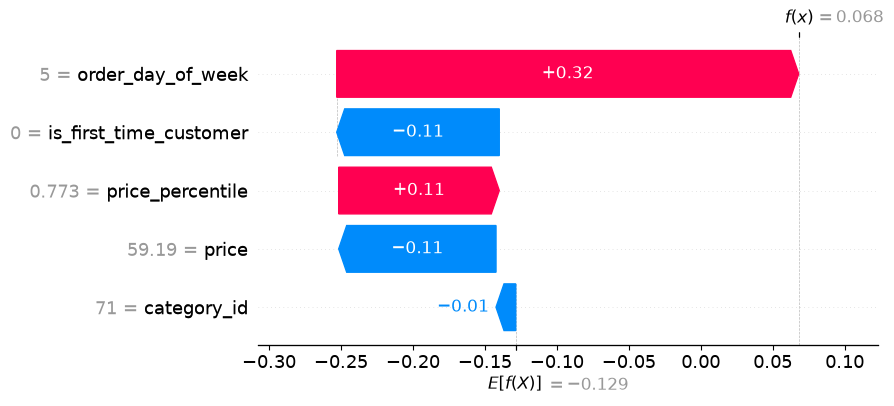

In [89]:
# plot for false positive example
shap.plots.waterfall(shap_values[indices_by_outcome['false_positives'][0]])